In [21]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatOllama(model="qwen3:1.7b")

class SentimentAnalysis(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the text, either 'positive' or 'negative'.")
    confidence: float = Field(description="The confidence score of the sentiment analysis, between 0 and 1.")
    reason: str = Field(description="A brief explanation of why the sentiment was classified as such.")

class SentimentState(TypedDict):
    original_tweet: str
    sentiment: str
    confidence: float
    response_tweet: str

In [22]:
def analyze_sentiment(state: SentimentState):
    messages = [
            SystemMessage(content="You are a helpful assistant that analyzes the sentiment of tweets and generates a response."),
            HumanMessage(content=f"Analyze the following tweet: '{state['original_tweet']}' and provide the sentiment, confidence score, and a response tweet.")
        ]

    structured_llm = llm.with_structured_output(SentimentAnalysis)

    parsed_response = structured_llm.invoke(messages)
    print(f'Sentiment Analysis Result: {parsed_response}')

    return {
        "sentiment": parsed_response.sentiment,
        "confidence": parsed_response.confidence,
    }

In [23]:
state = {'original_tweet': "I love this new phone! It's amazing."}
sentiment_result = analyze_sentiment(state)
sentiment_result

Sentiment Analysis Result: sentiment='positive' confidence=0.95 reason="The tweet uses strong positive language ('love', 'amazing') and exclamation marks, indicating high emotional intensity. The sentiment is clearly positive with no ambiguity."


{'sentiment': 'positive', 'confidence': 0.95}

In [24]:
def generate_negative_response(state: SentimentState):
    messages = [
            SystemMessage(content="You are a helpful assistant that generates a response to a negative tweet."),
            HumanMessage(content=f"The original tweet is: '{state['original_tweet']}'. The sentiment is: '{state['sentiment']}' with confidence {state['confidence']}. Generate a response tweet that addresses the negative sentiment.")
        ]

    response = llm.invoke(messages)
    print(f'Generated Response Tweet: {response}')

    return {'response_tweet': response.content.strip()}

In [25]:
def generate_positive_response(state: SentimentState):
    messages = [
            SystemMessage(content="You are a helpful assistant that generates a response to a positive tweet."),
            HumanMessage(content=f"The original tweet is: '{state['original_tweet']}'. The sentiment is: '{state['sentiment']}' with confidence {state['confidence']}. Generate a response tweet that acknowledges the positive sentiment.")
        ]

    response = llm.invoke(messages)
    print(f'Generated Response Tweet: {response}')

    return {'response_tweet': response.content.strip()}

In [29]:
def route_by_sentiment(state: SentimentState):
    if state['sentiment'] == 'negative':
        return "generate_negative_response"
    else:
        return "generate_positive_response"

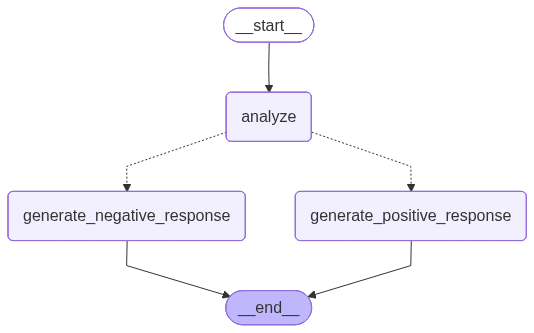

In [30]:
builder = StateGraph(SentimentState)

builder.add_node("analyze", analyze_sentiment)
builder.add_node("generate_negative_response", generate_negative_response)
builder.add_node("generate_positive_response", generate_positive_response)

builder.add_edge(START,"analyze")
builder.add_conditional_edges("analyze", route_by_sentiment, ["generate_negative_response", "generate_positive_response"])

builder.add_edge("generate_negative_response", END)
builder.add_edge("generate_positive_response", END)

graph = builder.compile()

graph

In [31]:
tweet = "I hate the new update! It's so buggy and slow."

result = graph.invoke({'original_tweet': tweet})
result

Sentiment Analysis Result: sentiment='negative' confidence=0.95 reason="The tweet contains strong negative words ('hate', 'buggy', 'slow') and provides specific complaints, indicating clear dissatisfaction."
Generated Response Tweet: content="I'm really sorry to hear that! The new update is definitely causing some issues—buggy and slow. If you'd like, I can help you troubleshoot or provide updates on the fix. Let me know how I can assist! #TechSupport #FeedbackNeeded" additional_kwargs={} response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-01T08:18:50.1281015Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13121117600, 'load_duration': 253001500, 'prompt_eval_count': 73, 'prompt_eval_duration': 1482753000, 'eval_count': 215, 'eval_duration': 11197306900, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'} id='lc_run--019ca87a-5b4e-7792-a26b-6500223d3bf2-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 73, 'output_tokens

{'original_tweet': "I hate the new update! It's so buggy and slow.",
 'sentiment': 'negative',
 'confidence': 0.95,
 'response_tweet': "I'm really sorry to hear that! The new update is definitely causing some issues—buggy and slow. If you'd like, I can help you troubleshoot or provide updates on the fix. Let me know how I can assist! #TechSupport #FeedbackNeeded"}